In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [6]:
df = pd.read_csv("shopping_trends.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [7]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:\n", df.columns)

print("\nDataset Info\n")
df.info()

Dataset Shape: (3900, 19)

Column Names:
 Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='str')

Dataset Info

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                

In [8]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [9]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [10]:
total_customers = df["Customer ID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 3900


In [11]:
interested_customers = df[df["Previous Purchases"] > 0]["Customer ID"].nunique()

print("Interested Customers:", interested_customers)

Interested Customers: 3900


In [12]:
promo_customers = df[df["Promo Code Used"] == "Yes"]["Customer ID"].nunique()

print("Customers Using Promo Code:", promo_customers)

Customers Using Promo Code: 1677


In [13]:
subscribed_customers = df[df["Subscription Status"] == "Yes"]["Customer ID"].nunique()

print("Subscribed Customers:", subscribed_customers)

Subscribed Customers: 1053


In [14]:
funnel = pd.DataFrame({
    "Stage": [
        "Total Customers",
        "Interested Customers",
        "Promo Code Users",
        "Subscribed Customers"
    ],
    "Count": [
        total_customers,
        interested_customers,
        promo_customers,
        subscribed_customers
    ]
})

funnel

,Stage,Count
0,Total Customers,3900
1,Interested Customers,3900
2,Promo Code Users,1677
3,Subscribed Customers,1053


C:\Users\HP\AppData\Local\Temp\ipykernel_20920\2900218666.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=funnel, x="Stage", y="Count", palette="viridis")


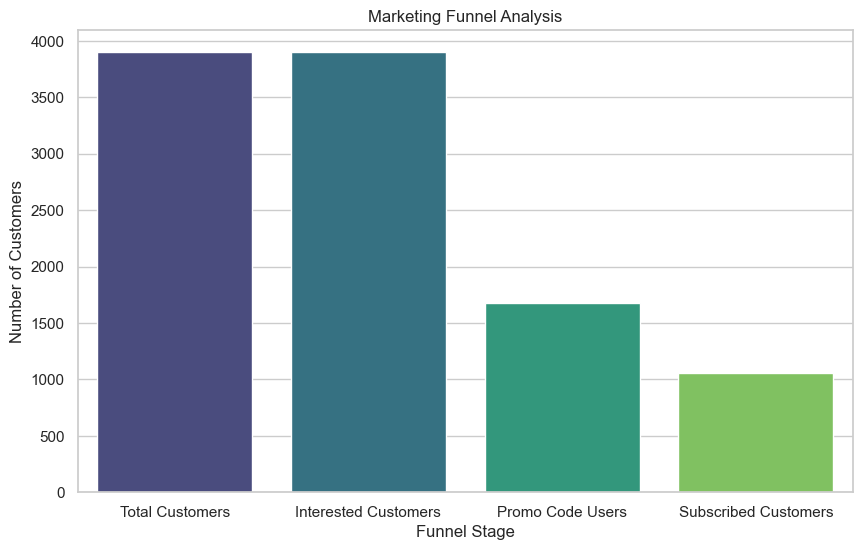

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(data=funnel, x="Stage", y="Count", palette="viridis")

plt.title("Marketing Funnel Analysis")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
category_sales = df.groupby("Category")["Purchase Amount (USD)"].sum().sort_values(ascending=False)

category_sales

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_20920\2630852542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index,


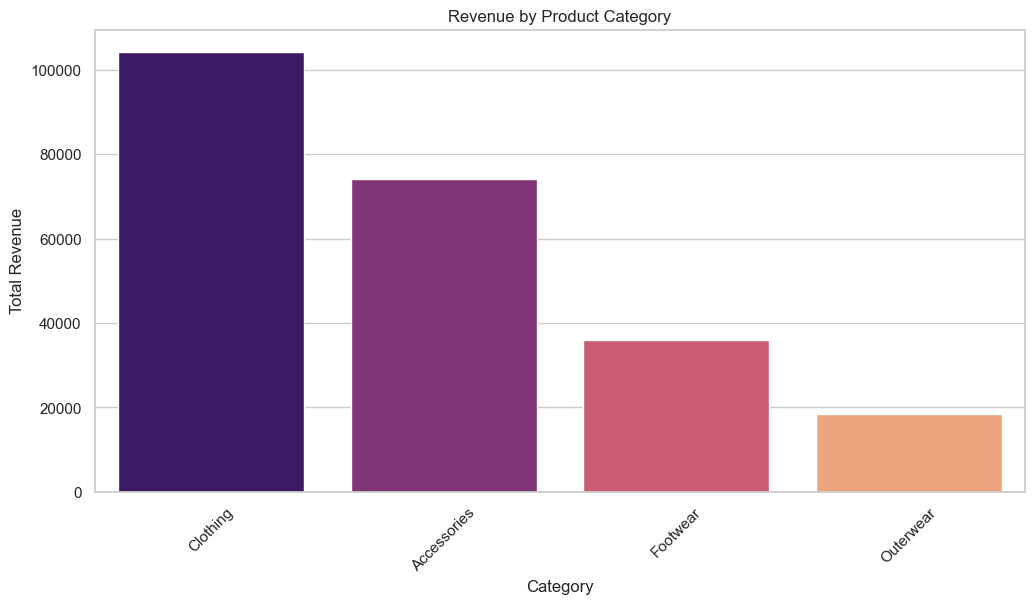

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(x=category_sales.index,
            y=category_sales.values,
            palette="magma")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

In [18]:
payment_counts = df["Payment Method"].value_counts()

payment_counts

Payment Method
Credit Card      696
Venmo            653
Cash             648
PayPal           638
Debit Card       633
Bank Transfer    632
Name: count, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_20920\3246605797.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Payment Method", palette="coolwarm")


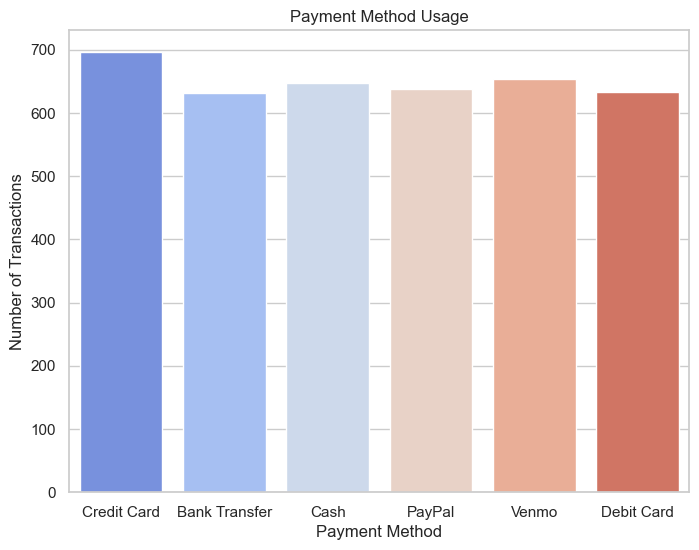

In [19]:
plt.figure(figsize=(8,6))

sns.countplot(data=df, x="Payment Method", palette="coolwarm")

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.show()

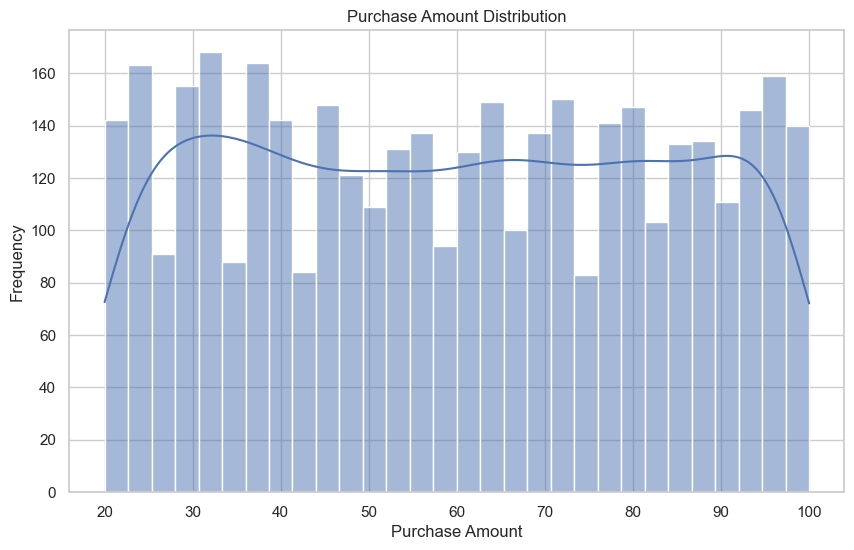

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(df["Purchase Amount (USD)"], bins=30, kde=True)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")

plt.show()

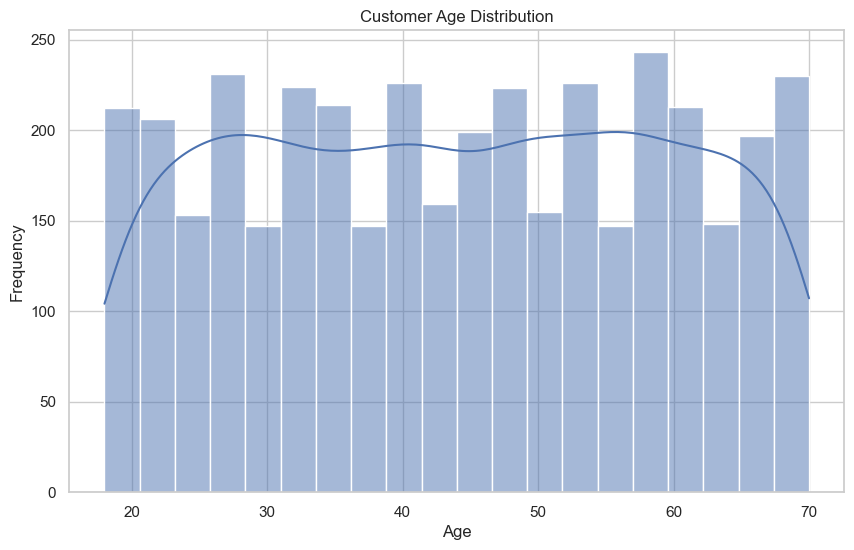

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [22]:
gender_sales = df.groupby("Gender")["Purchase Amount (USD)"].sum()

gender_sales

Gender
Female     75191
Male      157890
Name: Purchase Amount (USD), dtype: int64

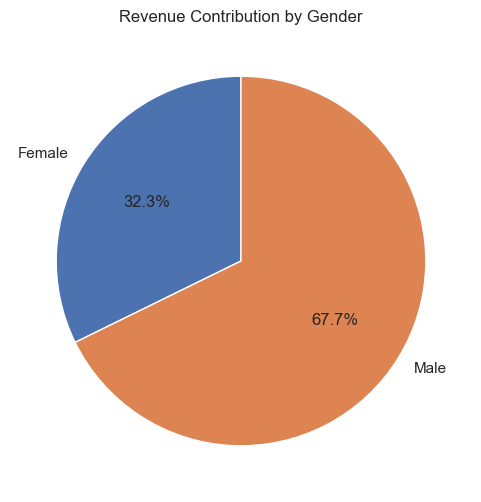

In [23]:
plt.figure(figsize=(6,6))

plt.pie(gender_sales,
        labels=gender_sales.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Revenue Contribution by Gender")

plt.show()

In [24]:
print("Key Business Insights\n")

print("1. Funnel analysis shows how many customers convert to subscribers.")
print("2. Promo code usage indicates marketing campaign effectiveness.")
print("3. Category revenue helps identify high performing product segments.")
print("4. Payment method analysis helps optimize checkout experience.")
print("5. Customer demographics help target marketing strategies.")

Key Business Insights

1. Funnel analysis shows how many customers convert to subscribers.
2. Promo code usage indicates marketing campaign effectiveness.
3. Category revenue helps identify high performing product segments.
4. Payment method analysis helps optimize checkout experience.
5. Customer demographics help target marketing strategies.


In [25]:
# Copy dataset
df_corr = df.copy()

# Convert Yes/No columns to numeric
df_corr["Subscription Status"] = df_corr["Subscription Status"].map({"Yes":1, "No":0})
df_corr["Promo Code Used"] = df_corr["Promo Code Used"].map({"Yes":1, "No":0})
df_corr["Discount Applied"] = df_corr["Discount Applied"].map({"Yes":1, "No":0})

# Select numeric columns
numeric_df = df_corr.select_dtypes(include=[np.number])

numeric_df.head()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases
0,1,55,53,3.1,1,1,1,14
1,2,19,64,3.1,1,1,1,2
2,3,50,73,3.1,1,1,1,23
3,4,21,90,3.5,1,1,1,49
4,5,45,49,2.7,1,1,1,31


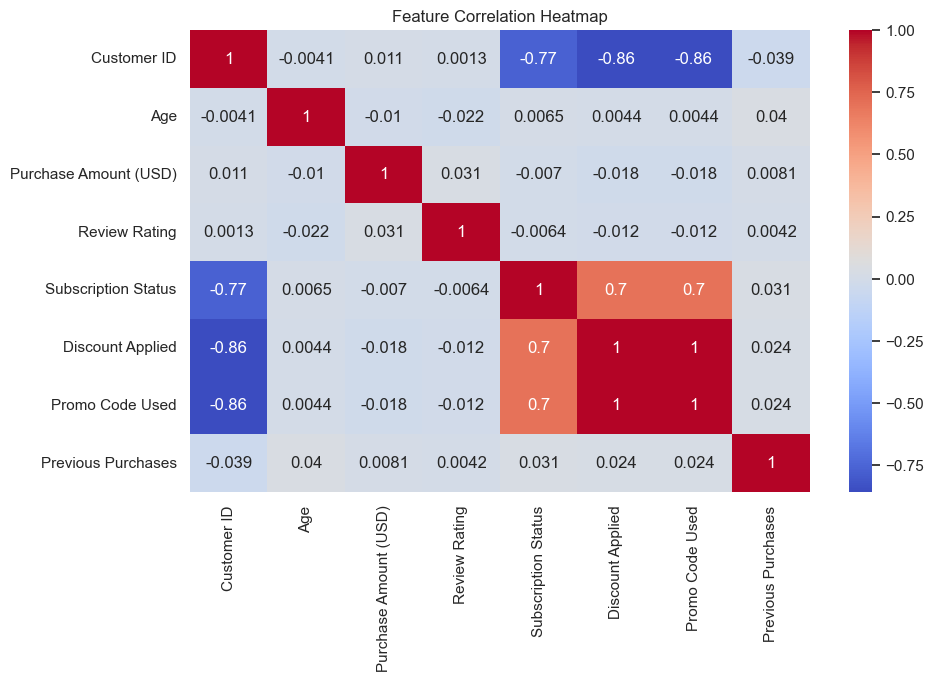

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [27]:
location_sales = df.groupby("Location")["Purchase Amount (USD)"].sum().sort_values(ascending=False)

top_locations = location_sales.head(10)

top_locations

Location
Montana          5784
Illinois         5617
California       5605
Idaho            5587
Nevada           5514
Alabama          5261
New York         5257
North Dakota     5220
West Virginia    5174
Nebraska         5172
Name: Purchase Amount (USD), dtype: int64

In [28]:
location_sales = df.groupby("Location")["Purchase Amount (USD)"].sum().sort_values(ascending=False)

top_locations = location_sales.head(10)

top_locations

Location
Montana          5784
Illinois         5617
California       5605
Idaho            5587
Nevada           5514
Alabama          5261
New York         5257
North Dakota     5220
West Virginia    5174
Nebraska         5172
Name: Purchase Amount (USD), dtype: int64

In [29]:
discount_sales = df.groupby("Discount Applied")["Purchase Amount (USD)"].mean()

discount_sales

Discount Applied
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64

C:\Users\HP\AppData\Local\Temp\ipykernel_20920\649598855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=discount_sales.index,


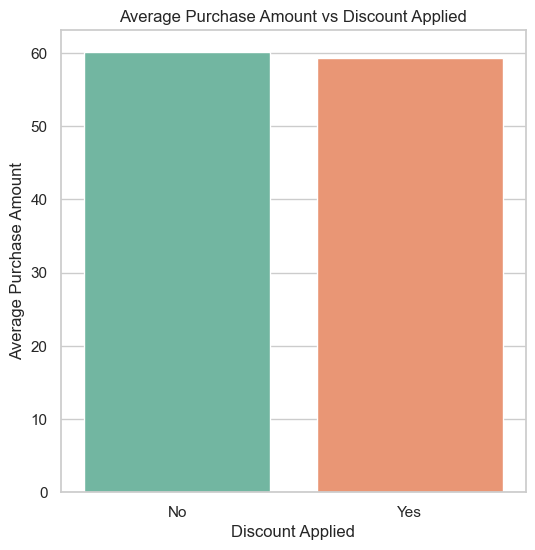

In [30]:
plt.figure(figsize=(6,6))

sns.barplot(x=discount_sales.index,
            y=discount_sales.values,
            palette="Set2")

plt.title("Average Purchase Amount vs Discount Applied")
plt.xlabel("Discount Applied")
plt.ylabel("Average Purchase Amount")

plt.show()

In [31]:
def customer_segment(x):
    
    if x >= 20:
        return "VIP Customer"
    
    elif x >= 10:
        return "Regular Customer"
    
    else:
        return "New Customer"


df["Customer Segment"] = df["Previous Purchases"].apply(customer_segment)

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Customer Segment
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,Regular Customer
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,New Customer
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,VIP Customer
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,VIP Customer
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,VIP Customer


In [32]:
segment_counts = df["Customer Segment"].value_counts()

segment_counts

Customer Segment
VIP Customer        2422
Regular Customer     770
New Customer         708
Name: count, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_20920\3481193873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


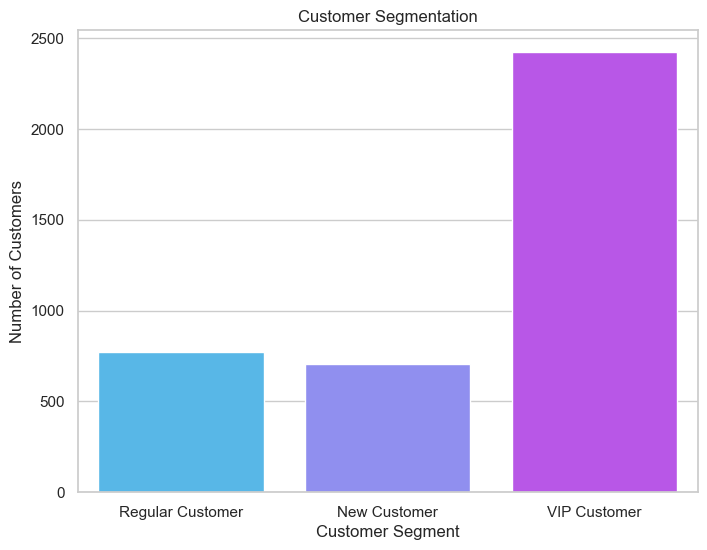

In [33]:
plt.figure(figsize=(8,6))

sns.countplot(data=df,
              x="Customer Segment",
              palette="cool")

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

In [34]:
segment_sales = df.groupby("Customer Segment")["Purchase Amount (USD)"].sum()

segment_sales

Customer Segment
New Customer         43142
Regular Customer     45169
VIP Customer        144770
Name: Purchase Amount (USD), dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_20920\451833659.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_sales.index,


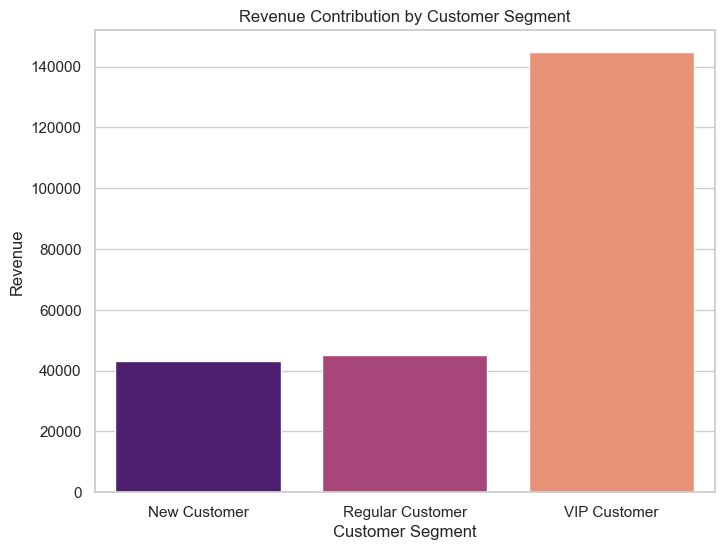

In [35]:
plt.figure(figsize=(8,6))

sns.barplot(x=segment_sales.index,
            y=segment_sales.values,
            palette="magma")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.show()

In [36]:
print("Final Business Insights and Recommendations:\n")

print("1. VIP customers generate significant revenue, so loyalty programs should target them.")
print("2. Promo codes and discounts influence customer purchasing behavior.")
print("3. Certain locations contribute more revenue, indicating strong regional demand.")
print("4. Category performance helps identify which products to promote more.")
print("5. Funnel analysis shows how marketing engagement converts customers to subscribers.")

Final Business Insights and Recommendations:

1. VIP customers generate significant revenue, so loyalty programs should target them.
2. Promo codes and discounts influence customer purchasing behavior.
3. Certain locations contribute more revenue, indicating strong regional demand.
4. Category performance helps identify which products to promote more.
5. Funnel analysis shows how marketing engagement converts customers to subscribers.


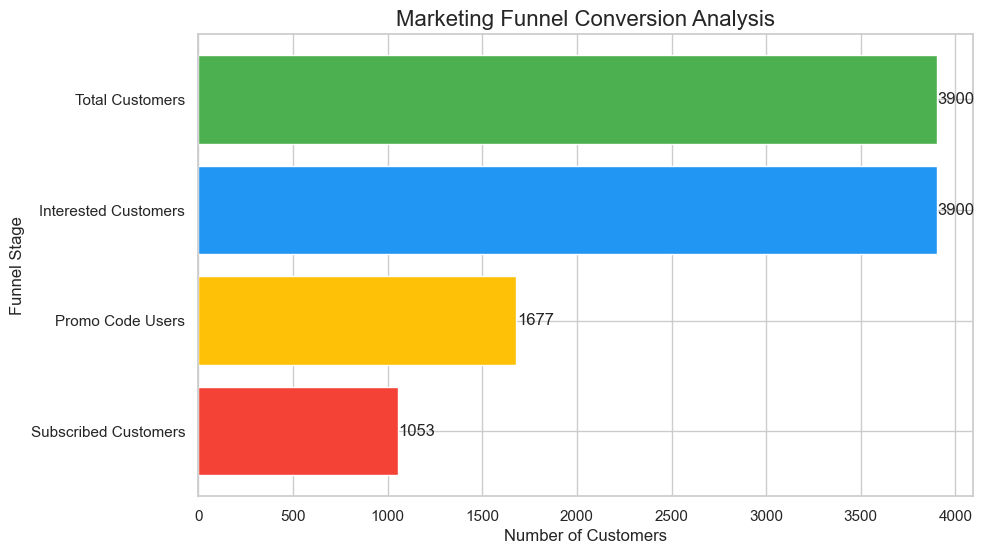

In [37]:
# Prepare funnel values
stages = [
    "Total Customers",
    "Interested Customers",
    "Promo Code Users",
    "Subscribed Customers"
]

values = [
    total_customers,
    interested_customers,
    promo_customers,
    subscribed_customers
]

# Create funnel plot
plt.figure(figsize=(10,6))

bars = plt.barh(stages, values, color=["#4CAF50","#2196F3","#FFC107","#F44336"])

plt.title("Marketing Funnel Conversion Analysis", fontsize=16)
plt.xlabel("Number of Customers")
plt.ylabel("Funnel Stage")

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center')

plt.gca().invert_yaxis()

plt.show()